In [2]:
from pricing.heston_option_pricing import train_network as train_network_heston, PINN as PINN_heston
from pricing.hd_option_pricing import train_network as train_network_hd, PINN as PINN_hd
from pricing.two_d_option_pricing import train_network as train_network_2d, PINN as PINN_2d
from support_tools.testing_tools import heston_2d_slice_test, bs_2d_slice_test
from support_tools.graphing_tools import plot_convergence, plot_3d_result

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import numpy as np

# Pricing options under Two-Dimensional Black-Scholes model

In [4]:
pinn_2d = PINN_2d(x_min=-5.0,
    x_max=5.0,
    T=4.0,
    r=0.05,
    sigma=0.2,
    call_put="Call",
    hidden = 50, depth = 5).to(device)

In [3]:
history = train_network_2d(
    pinn=pinn_2d,
    n_pde=2000,
    n_boundary=1000,
    epochs=40000,
    save_model=True,
    best_model_path=r'trained_models/two_d.pt',
    lambda_boundary=0.3,
    lambda_terminal=0.5,   
    grad_clip=1.0,
    print_every=100,
    lr=7e-3,
)

Epoch      1 | Time:       0.04s | LR: 7.000e-03 | Total: 8.125417e-01 | PDE_x: 9.764444e-04 | Terminal_x: 5.028131e-01 | Boundary_x: 1.867196e+00 | GradNorm: 5.263e-01 | Best: 8.125417e-01 @ 1
Epoch    100 | Time:       2.73s | LR: 7.000e-03 | Total: 6.173781e-01 | PDE_x: 6.881674e-06 | Terminal_x: 3.455659e-01 | Boundary_x: 1.481961e+00 | GradNorm: 3.940e-03 | Best: 6.026493e-01 @ 88
Epoch    200 | Time:       5.68s | LR: 7.000e-03 | Total: 5.354300e-01 | PDE_x: 4.477233e-02 | Terminal_x: 1.823547e-01 | Boundary_x: 1.331601e+00 | GradNorm: 6.850e-01 | Best: 4.788266e-01 @ 188
Epoch    300 | Time:       9.03s | LR: 6.999e-03 | Total: 3.868008e-01 | PDE_x: 5.070147e-03 | Terminal_x: 6.643854e-02 | Boundary_x: 1.161705e+00 | GradNorm: 2.226e-01 | Best: 3.821873e-01 @ 299
Epoch    400 | Time:      12.02s | LR: 6.998e-03 | Total: 3.427419e-01 | PDE_x: 2.779235e-02 | Terminal_x: 4.601583e-02 | Boundary_x: 9.731388e-01 | GradNorm: 5.793e-01 | Best: 3.284873e-01 @ 389
Epoch    500 | Time:   

In [5]:
state_dict = torch.load(r'trained_models/two_d.pt', weights_only=True)['model_state_dict']
pinn_2d.load_state_dict(state_dict)
pinn_2d.eval()

PINN(
  (trunk): Sequential(
    (0): Linear(in_features=5, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): Tanh()
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): Tanh()
  )
  (head_gate): Linear(in_features=50, out_features=1, bias=True)
)

In [ ]:
def pinn_price_delta_theta(pinn, S, K, tau, device=None, create_graph=False):
    """
    Compute price, Delta, and Theta from a trained PINN.

    Inputs:
        pinn : trained PINN instance.
        S    : float or 1D array-like of spot prices.
        K    : float or 1D array-like of strikes (broadcastable with S).
        tau  : float or 1D array-like of times-to-maturity (T - t).
        device : torch device; if None, use pinn's device.
        create_graph : if True, keep graph for higher-order Greeks.

    Returns:
        price : torch.Tensor of shape (N, 1)
        delta : torch.Tensor of shape (N, 1)
        theta : torch.Tensor of shape (N, 1), where theta = ∂V/∂t
    """
    if device is None:
        device = next(pinn.parameters()).device

    # Convert inputs to tensors on correct device
    S_t = torch.as_tensor(S, dtype=torch.float32, device=device).reshape(-1, 1)
    K_t = torch.as_tensor(K, dtype=torch.float32, device=device).reshape(-1, 1)
    tau_t = torch.as_tensor(tau, dtype=torch.float32, device=device).reshape(-1, 1)

    # We need gradients w.r.t. S and tau
    S_t.requires_grad_(True)
    tau_t.requires_grad_(True)

    # Forward pass: V = K * u(x, tau)
    V = pinn.forward(S_t, K_t, tau_t) * K_t   # forward() returns u = V/K

    # We want gradients of V
    ones = torch.ones_like(V)

    # Delta = ∂V/∂S
    (dV_dS,) = torch.autograd.grad(
        outputs=V,
        inputs=S_t,
        grad_outputs=ones,
        create_graph=create_graph,
        retain_graph=True,
    )

    # dV/dtau
    (dV_dtau,) = torch.autograd.grad(
        outputs=V,
        inputs=tau_t,
        grad_outputs=ones,
        create_graph=create_graph,
        retain_graph=create_graph,
    )

    # Theta in calendar time t: t = T - tau => ∂V/∂t = -∂V/∂tau
    theta = -dV_dtau

    return V.detach(), dV_dS.detach(), theta.detach()

In [16]:
# suppose pinn is trained and on some device
S0 = 100.0
K0 = 100.0
tau0 = 0.5   # time to maturity

price, delta, theta = pinn_price_delta_theta(pinn_2d, S0, K0, tau0)
print("Price:", price.item())
print("Delta:", delta.item())
print("Theta:", theta.item())

Price: 7.289119720458984
Delta: 0.6253597140312195
Theta: -7.514772415161133


In [8]:

pinn_2d.predict_price(150., 100., 1.0)

tensor([[55.4121]])

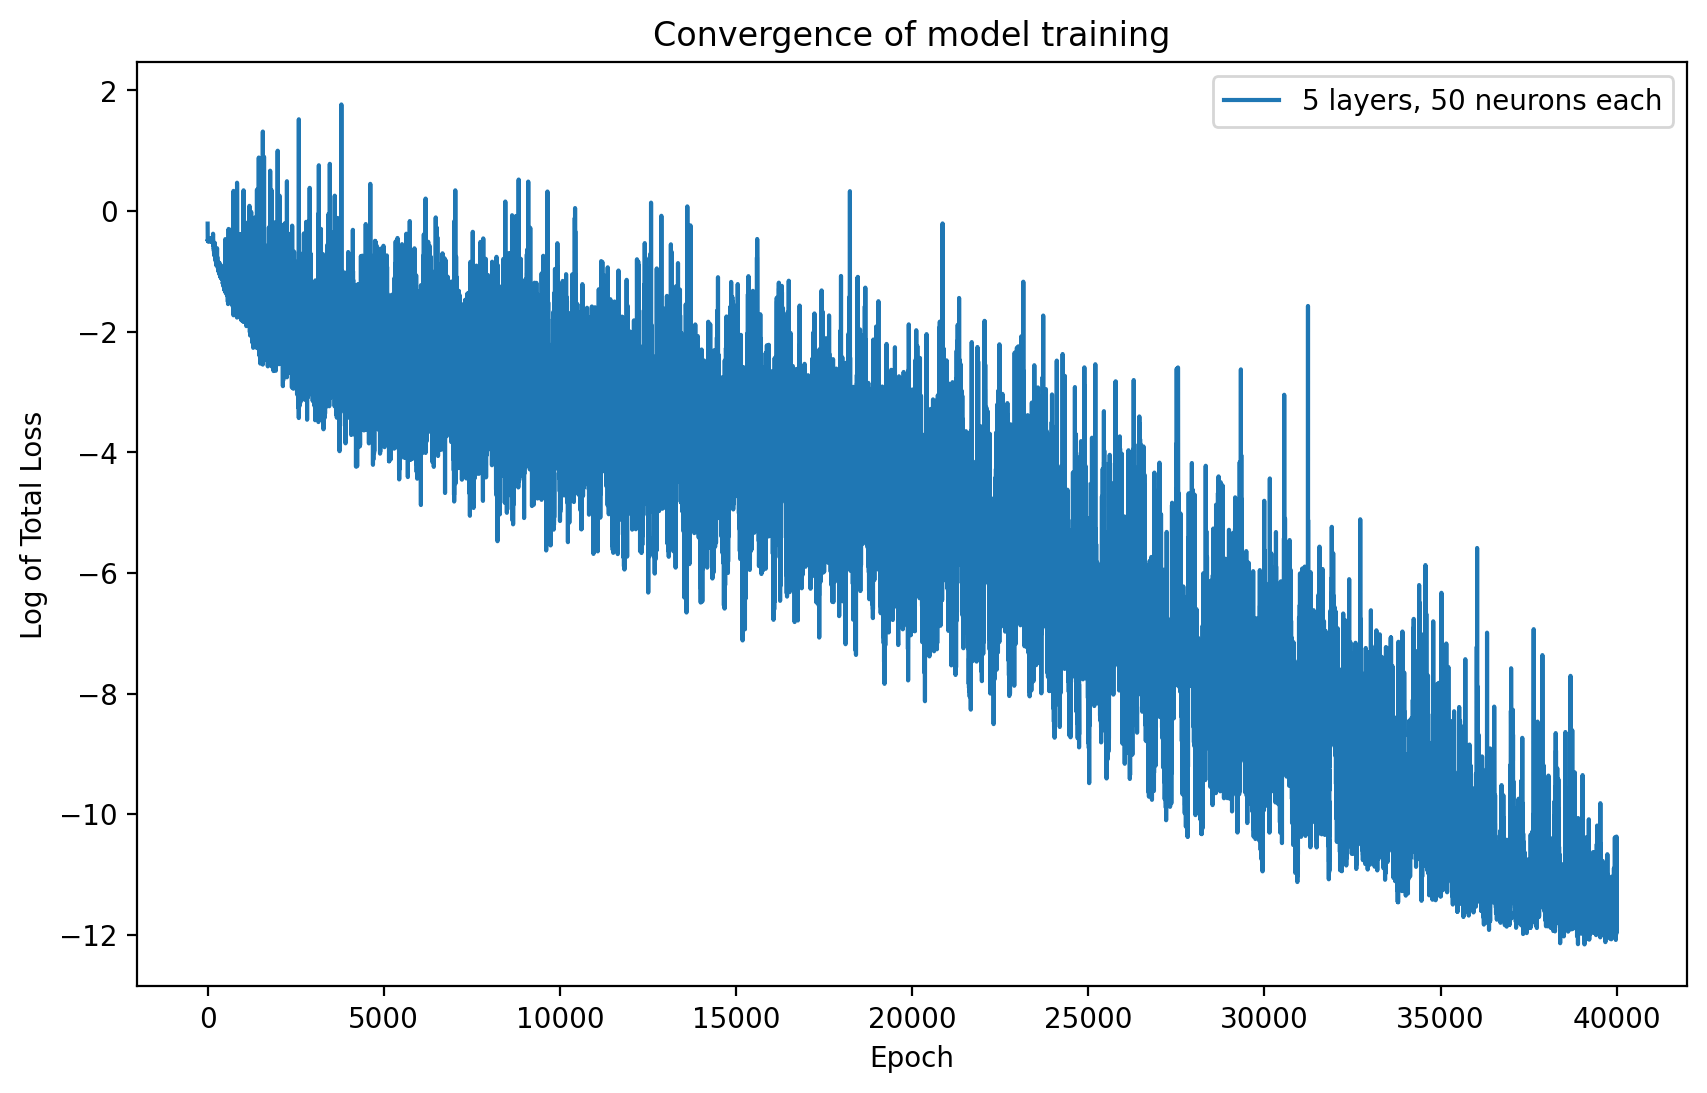

In [5]:
plot_convergence(history, x_axis = 'epochs')

In [8]:
results = bs_2d_slice_test(pinn_2d, return_values = True, r=0.05, sigma_bs=0.2, K=100, s_max=500, s_step=2)

MSE = 0.06458063839928935
RMSE = 0.2541272090888525
MAE = 0.2001143842366147


In [30]:
import numpy as np
import torch
from math import log, sqrt, exp, erf
import scipy.stats as st


import numpy as np

def _norm_cdf(x):
    """
    Standard normal CDF, vectorized via scipy.stats.norm.cdf.
    """
    return st.norm.cdf(x)


def bs_delta_theta_analytic(S, K, tau, r, sigma, call_put="call"):
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    tau = np.asarray(tau, dtype=float)

    cp = call_put.lower()
    eps = 1e-12
    tau_eff = np.maximum(tau, eps)
    S_eff = np.maximum(S, eps)
    sigma_eff = max(sigma, eps)

    d1 = (np.log(S_eff / K) + (r + 0.5 * sigma_eff**2) * tau_eff) / (sigma_eff * np.sqrt(tau_eff))
    d2 = d1 - sigma_eff * np.sqrt(tau_eff)

    if cp == "call":
        delta = _norm_cdf(d1)
        theta = (
            - (S_eff * sigma_eff * np.exp(-0.5 * d1**2) / np.sqrt(2.0 * np.pi * tau_eff))
            - r * K * np.exp(-r * tau_eff) * _norm_cdf(d2)
        )
    else:
        delta = _norm_cdf(d1) - 1.0
        theta = (
            - (S_eff * sigma_eff * np.exp(-0.5 * d1**2) / np.sqrt(2.0 * np.pi * tau_eff))
            + r * K * np.exp(-r * tau_eff) * _norm_cdf(-d2)
        )

    return delta, theta

def compare_pinn_vs_bs_greeks(
    pinn,
    K=1.0,
    r=0.05,
    sigma=0.2,
    call_put="call",
    m_min=0.5,
    m_max=1.5,
    n_m=25,
    tau_min=0.05,
    tau_max=None,
    n_tau=25,
    device=None,
):
    """
    Compare PINN Delta/Theta against analytic BS on a grid of (S/K, tau).

    Grid:
        m = S/K in [m_min, m_max], tau in [tau_min, tau_max or pinn.T]

    Returns:
        delta_anal  : tensor (n_tau, n_m)
        delta_pinn  : tensor (n_tau, n_m)
        delta_diff  : tensor (n_tau, n_m)
        theta_anal  : tensor (n_tau, n_m)
        theta_pinn  : tensor (n_tau, n_m)
        theta_diff  : tensor (n_tau, n_m)
    """
    if device is None:
        device = next(pinn.parameters()).device

    if tau_max is None:
        tau_max = pinn.T

    # 1) Build grid in m = S/K and tau
    m_vals = np.linspace(m_min, m_max, n_m)
    tau_vals = np.linspace(tau_min, tau_max, n_tau)

    # Prepare full mesh
    M_grid, Tau_grid = np.meshgrid(m_vals, tau_vals)  # shape (n_tau, n_m)
    S_grid = K * M_grid

    # 2) Flatten for batched PINN evaluation
    S_flat = S_grid.reshape(-1)
    K_flat = np.full_like(S_flat, K, dtype=float)
    Tau_flat = Tau_grid.reshape(-1)

    # 3) PINN price, Delta, Theta (calendar) on flattened grid
    V_pinn, delta_pinn_flat, theta_pinn_flat = pinn_price_delta_theta(
        pinn,
        S=S_flat,
        K=K_flat,
        tau=Tau_flat,
        device=device,
        create_graph=False,
    )
    # detach and reshape to grid
    delta_pinn = delta_pinn_flat.cpu().numpy().reshape(n_tau, n_m)
    theta_pinn = theta_pinn_flat.cpu().numpy().reshape(n_tau, n_m)

    # 4) Analytic BS Delta, Theta
    delta_anal, theta_anal = bs_delta_theta_analytic(
        S=S_grid,
        K=K,
        tau=Tau_grid,
        r=r,
        sigma=sigma,
        call_put=call_put,
    )

    # 5) Differences
    delta_diff = delta_pinn - delta_anal
    theta_diff = theta_pinn - theta_anal

    # Wrap outputs as torch tensors for easier downstream use
    delta_anal_t = torch.as_tensor(delta_anal, dtype=torch.float32)
    delta_pinn_t = torch.as_tensor(delta_pinn, dtype=torch.float32)
    delta_diff_t = torch.as_tensor(delta_diff, dtype=torch.float32)

    theta_anal_t = torch.as_tensor(theta_anal, dtype=torch.float32)
    theta_pinn_t = torch.as_tensor(theta_pinn, dtype=torch.float32)
    theta_diff_t = torch.as_tensor(theta_diff, dtype=torch.float32)

    return (
        delta_anal_t,
        delta_pinn_t,
        delta_diff_t,
        theta_anal_t,
        theta_pinn_t,
        theta_diff_t,
        M_grid, Tau_grid
    )

In [ ]:
(
    delta_anal,
    delta_pinn,
    delta_diff,
    theta_anal,
    theta_pinn,
    theta_diff,
    M_grid, Tau_grid
) = compare_pinn_vs_bs_greeks(
    pinn_2d,
    K=1.0,
    r=pinn_2d.r,
    sigma=pinn_2d.sigma,
    call_put=pinn_2d.call_put,
    m_min=0.5,
    m_max=1.5,
    n_m=41,
    tau_min=0.05,
    tau_max=pinn_2d.T,
    n_tau=41,
)

print("Max |Δ error|:", delta_diff.abs().max().item())
print("Max |Θ error|:", theta_diff.abs().max().item())

Max |Δ error|: 0.17815370857715607
Max |Θ error|: 0.2841625213623047


In [48]:
torch.sqrt((theta_diff ** 2).mean())

tensor(0.0245)

In [39]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
            x=M_grid,
            y=Tau_grid,
            z=theta_diff,
            colorscale='jet',
            opacity=0.8,
        )])

fig.update_layout(
            title='Interactive Black-Scholes PDE solution',
            scene=dict(
                xaxis_title='Spot price (S)',
                yaxis_title='Time (tau)',
                # zaxis_title=title,
            ),
            autosize=True,
            width=900,
            height=700,
        )

fig.show()

In [12]:
plot_3d_result(results, 'diff')

# Pricing options under High-Dimensional Black-Scholes model

In [13]:
pinn_hd = PINN_hd(x_min=-3,
    x_max=3,
    T=4.0,
    r_max=0.4,
    sigma_max=0.7,
    call_put="Call",
    hidden = 100, depth = 3).to(device)

In [17]:
history = train_network_hd(
    pinn=pinn_hd,
    n_pde=1000,
    n_boundary=200,
    epochs=20000,
    save_model=True,
    best_model_path=r'trained_models/hd_minimal.pt',
    lambda_boundary=1.0,
    lambda_terminal=1.0,   
    grad_clip=1.0,
    print_every=1000,
    lr=1e-3,
)

Epoch      1 | Time:       0.03s | LR: 1.000e-03 | Total: 9.579068e-04 | PDE_x: 9.279132e-04 | Terminal_x: 2.758794e-05 | Boundary_x: 2.405688e-06 | GradNorm: 3.983e-02 | Best: 9.579068e-04 @ 1
Epoch   1000 | Time:      14.86s | LR: 7.575e-04 | Total: 1.641360e-03 | PDE_x: 1.238270e-03 | Terminal_x: 3.474658e-04 | Boundary_x: 5.562380e-05 | GradNorm: 1.604e-01 | Best: 7.625262e-05 @ 710
Epoch   2000 | Time:      30.06s | LR: 2.725e-04 | Total: 8.332162e-05 | PDE_x: 5.021475e-05 | Terminal_x: 3.026753e-05 | Boundary_x: 2.839339e-06 | GradNorm: 1.097e-02 | Best: 6.467388e-05 @ 1373
Epoch   3000 | Time:      45.19s | LR: 1.000e-03 | Total: 9.157052e-05 | PDE_x: 6.223015e-05 | Terminal_x: 2.711447e-05 | Boundary_x: 2.225902e-06 | GradNorm: 1.501e-02 | Best: 5.232233e-05 @ 2699
Epoch   4000 | Time:      60.51s | LR: 7.575e-04 | Total: 1.082842e-03 | PDE_x: 5.583626e-04 | Terminal_x: 1.469902e-04 | Boundary_x: 3.774894e-04 | GradNorm: 1.528e-01 | Best: 5.232233e-05 @ 2699
Epoch   5000 | Time

In [15]:
state_dict = torch.load(r'trained_models/hd_minimal.pt', weights_only=True)['model_state_dict']
pinn_hd.load_state_dict(state_dict)
pinn_hd.eval()

PINN(
  (trunk): Sequential(
    (0): Linear(in_features=9, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): Tanh()
  )
  (head_gate): Linear(in_features=100, out_features=1, bias=True)
  (head_corr): Linear(in_features=100, out_features=1, bias=True)
)

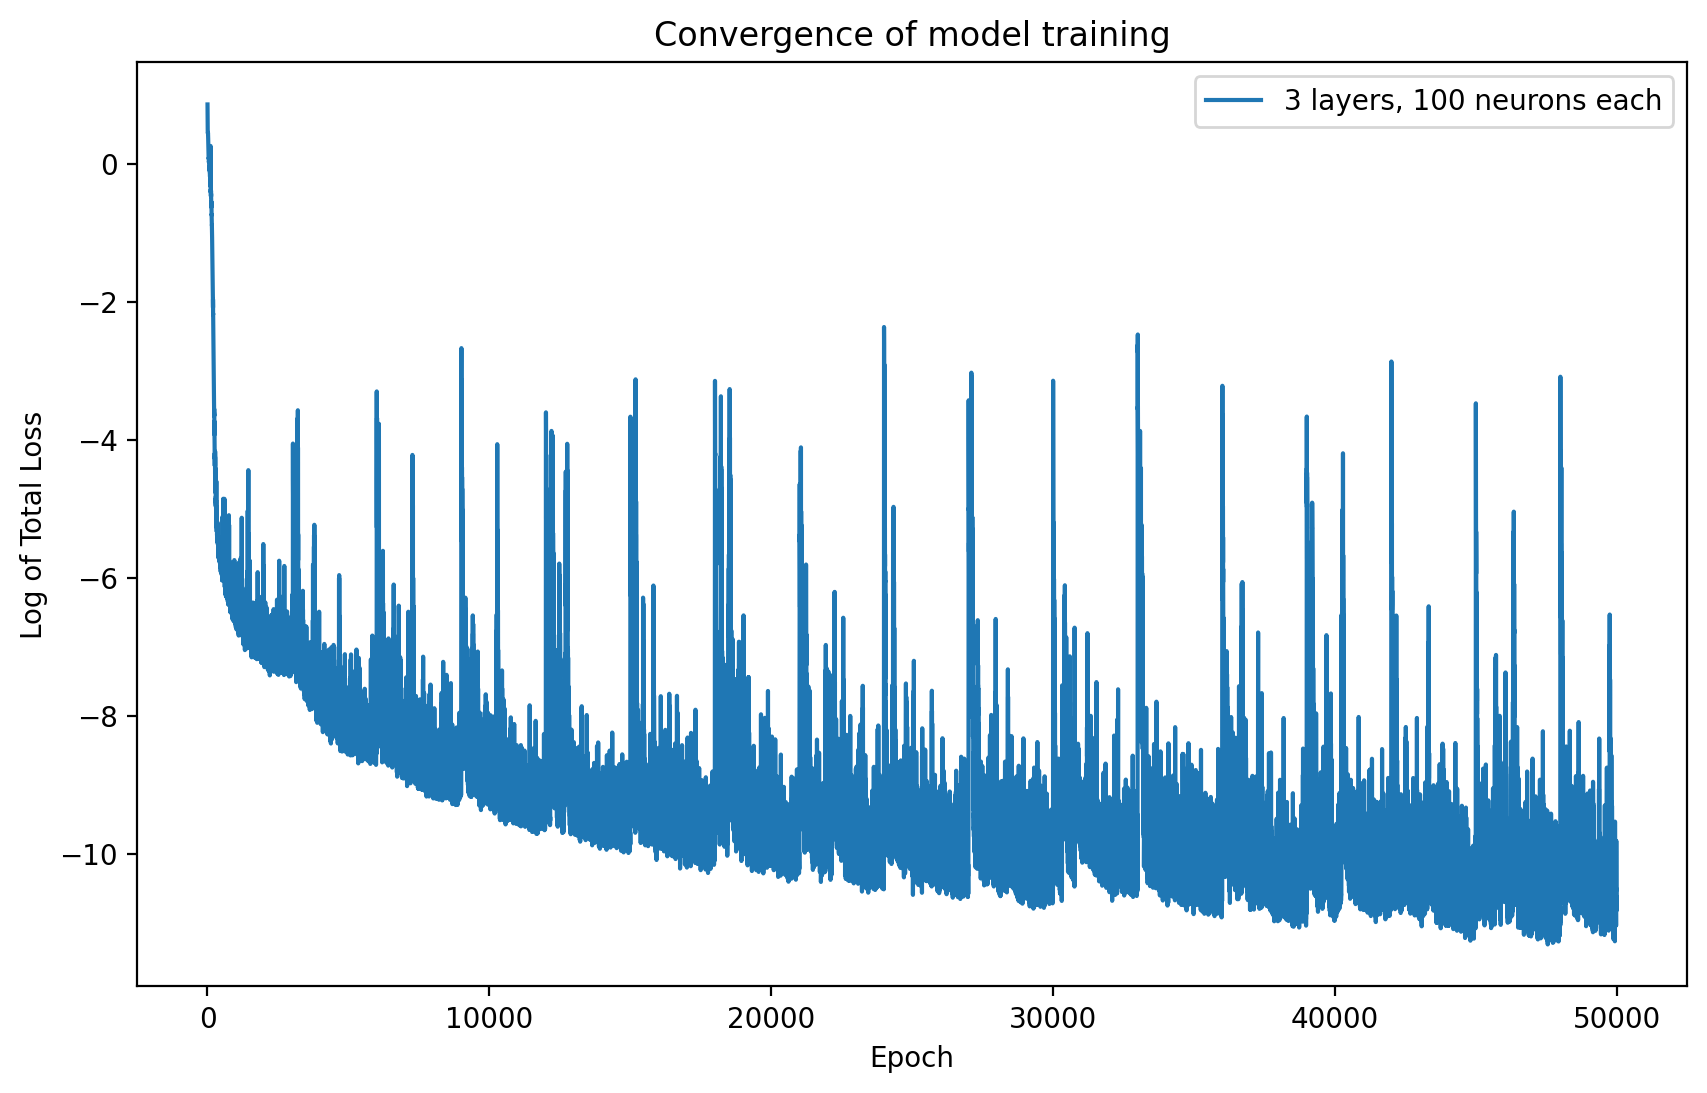

In [26]:
plot_convergence(history, x_axis = 'epochs')

In [22]:
pinn_hd.predict_price(S = 200., K = 100., tau = 2., r = 0.05, sigma = 0.2)

tensor([[109.6649]])

In [19]:
results = bs_2d_slice_test(pinn_hd, r=0.05, sigma_bs=0.2, K=100, s_max=500, s_step=2, return_values=True)

MSE = 0.07715342547650547
RMSE = 0.27776505445520944
MAE = 0.21140778837065677


In [21]:
plot_3d_result(results, 'diff')

In [17]:
models = [PINN_hd(x_min=-3,
                    x_max=3,
                    T=4.0,
                    r_max=0.4,
                    sigma_max=0.7,
                    call_put="Call",
                    hidden = 30, depth = 3).to(device),
            PINN_hd(x_min=-3,
                    x_max=3,
                    T=4.0,
                    r_max=0.4,
                    sigma_max=0.7,
                    call_put="Call",
                    hidden = 50, depth = 3).to(device),
            PINN_hd(x_min=-3,
                    x_max=3,
                    T=4.0,
                    r_max=0.4,
                    sigma_max=0.7,
                    call_put="Call",
                    hidden = 70, depth = 3).to(device)
            ]

In [18]:
histories = []
for model in models:
    histories.append(train_network_hd(pinn=model,
                                        n_pde=4000,
                                        n_boundary=1000,
                                        epochs=30000,
                                        save_model=False,
                                        best_model_path=r'trained_models/hd_minimal.pt',
                                        lambda_boundary=1.0,
                                        lambda_terminal=1.0,   
                                        grad_clip=1.0,
                                        print_every=5000,
                                        lr=1e-3,
                                    ))

Epoch      1 | Time:       0.02s | LR: 1.000e-03 | Total: 2.064206e+00 | PDE_x: 2.160036e-02 | Terminal_x: 3.753152e-01 | Boundary_x: 1.667290e+00 | GradNorm: 1.539e+00 | Best: 2.064206e+00 @ 1
Epoch   5000 | Time:    1263.73s | LR: 2.725e-04 | Total: 6.705672e-04 | PDE_x: 5.217809e-04 | Terminal_x: 1.321202e-04 | Boundary_x: 1.666611e-05 | GradNorm: 2.400e-02 | Best: 6.577283e-04 @ 4776
Epoch  10000 | Time:    1340.17s | LR: 7.575e-04 | Total: 3.786565e-04 | PDE_x: 2.810209e-04 | Terminal_x: 8.840027e-05 | Boundary_x: 9.235323e-06 | GradNorm: 6.010e-02 | Best: 2.122802e-04 @ 9941
Epoch  15000 | Time:    1413.00s | LR: 1.000e-03 | Total: 1.622287e-04 | PDE_x: 1.348843e-04 | Terminal_x: 2.412574e-05 | Boundary_x: 3.218745e-06 | GradNorm: 1.828e-02 | Best: 1.161448e-04 @ 14876
Epoch  20000 | Time:    1486.16s | LR: 2.725e-04 | Total: 1.174365e-04 | PDE_x: 8.011985e-05 | Terminal_x: 3.494593e-05 | Boundary_x: 2.370757e-06 | GradNorm: 2.288e-02 | Best: 8.227562e-05 @ 19588
Epoch  25000 | T

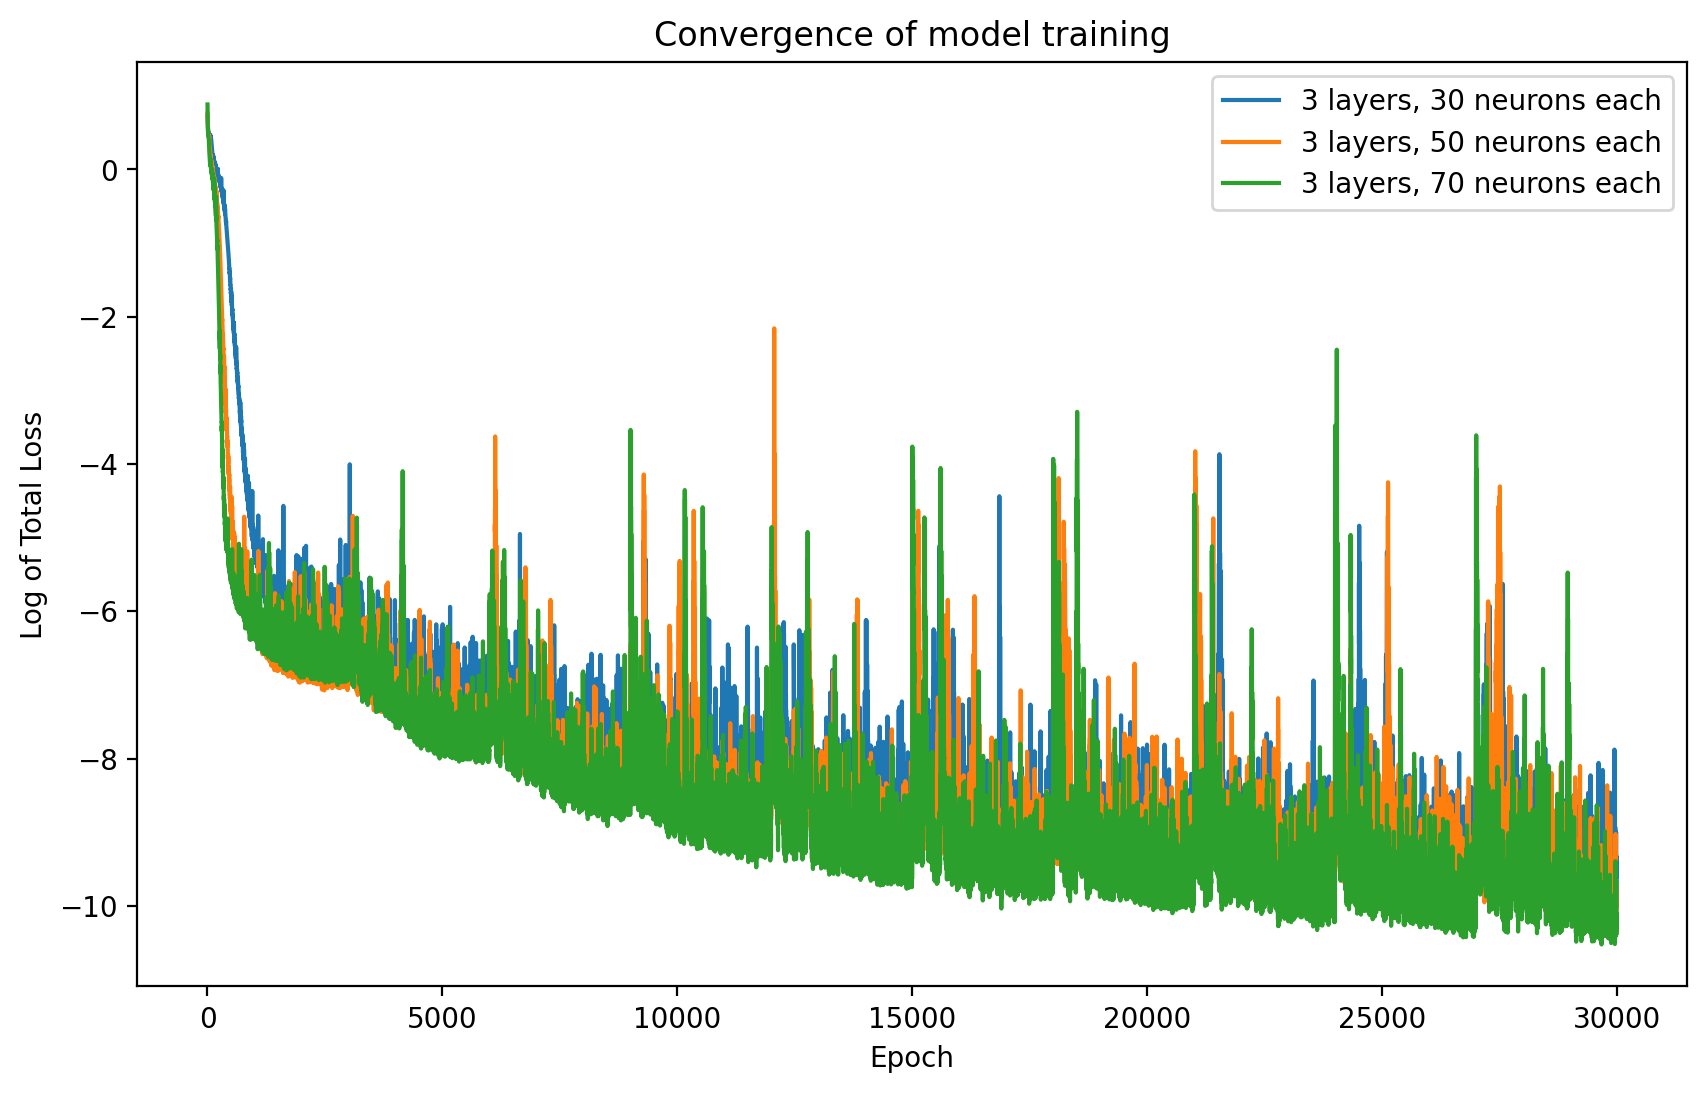

In [19]:
plot_convergence(histories, x_axis = 'epochs')

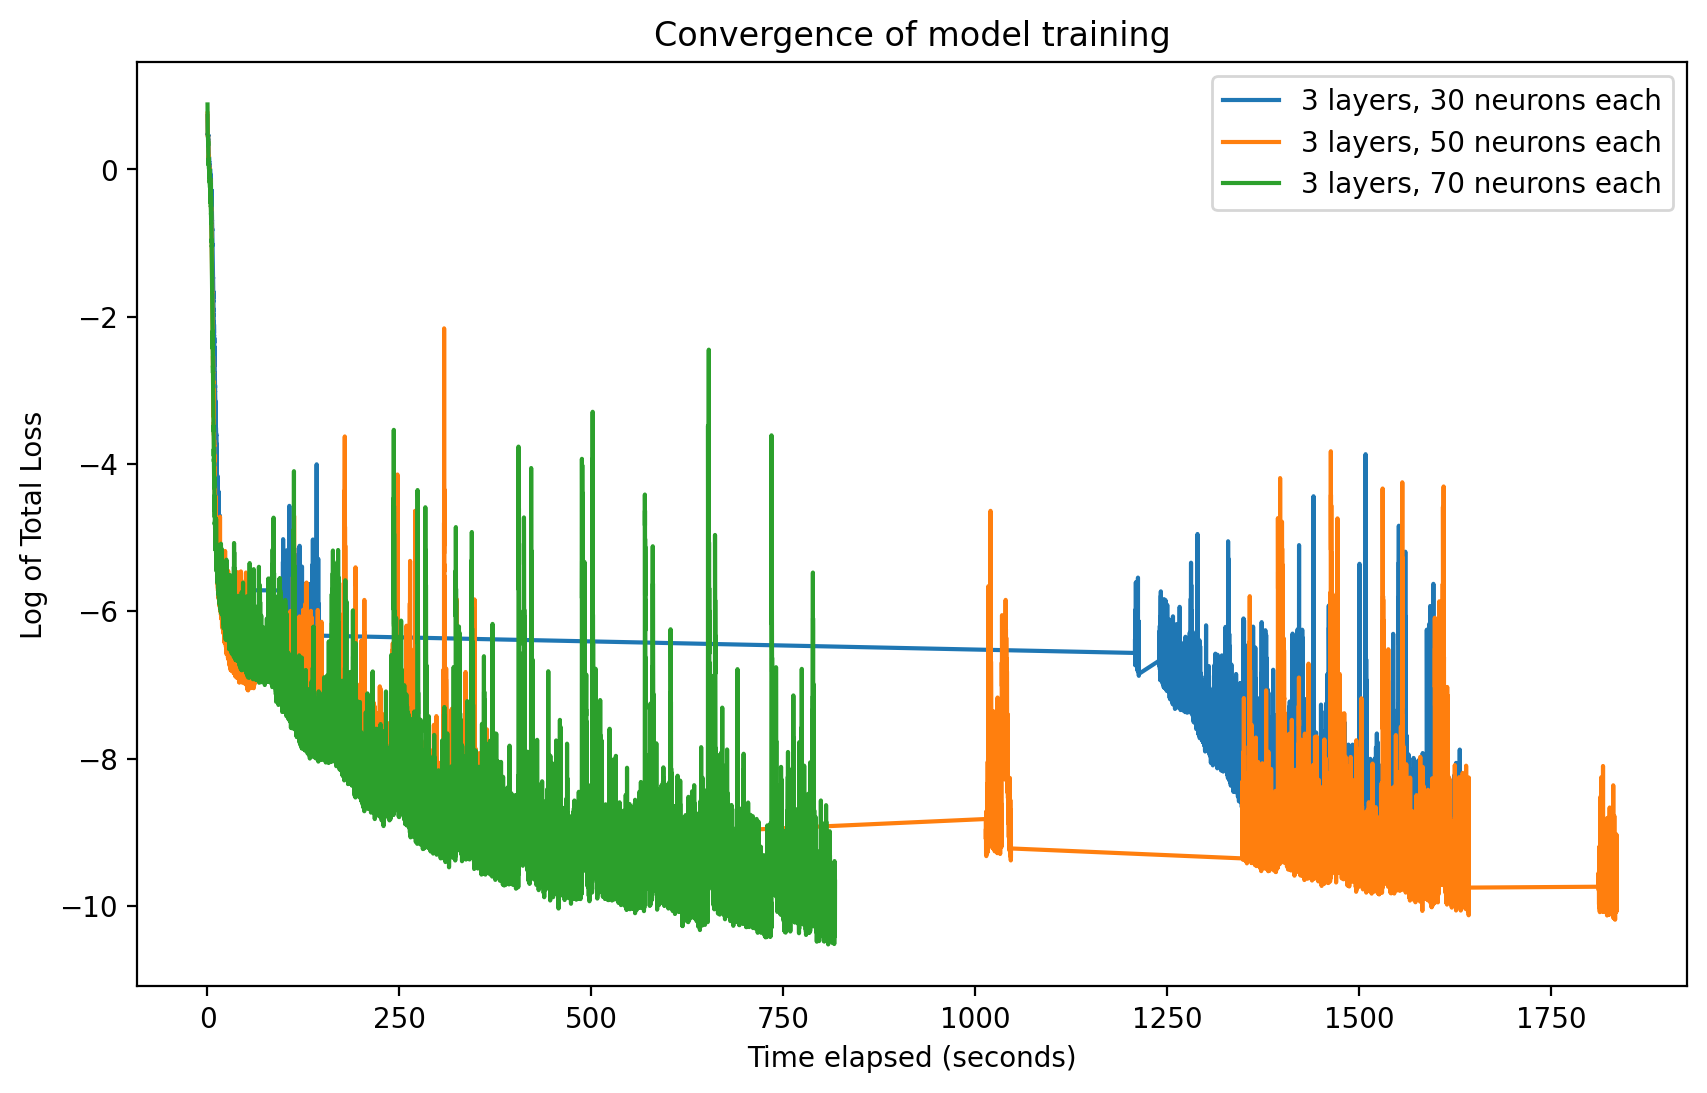

In [20]:
plot_convergence(histories, x_axis = 'time_elapsed')

# Pricing options under Heston model

In [ ]:
# setting up a model
pinn = PINN_heston(
    x_min=-5.0,
    x_max=5.0,
    v_max=0.5,
    T=4.0,
    r_max=0.4,
    kappa_max=5.0,
    theta_max=0.5,
    sigma_max=0.5,
    call_put="Call",
    hidden=120,
    depth=6
).to(device)

In [7]:
# either train the model...
history = train_network_heston(
    pinn=pinn,
    N_pde=4000,
    N_boundary=1000,
    epochs=10000,
    sigma_mode="mean_reverting",
    save_model=True,
    best_model_path=r'trained_models/long_training_heston.pt',
    lambda_boundary=1.0,
    lambda_terminal=1.0,   
    grad_clip=1.0,
    print_every=100,
    lr=1e-4,               
)

Epoch      1 | Time:       0.20s | LR: 1.000e-04 | Total: 1.125563e+00 | PDE_x: 2.780525e-02 | Terminal_x: 1.001513e-01 | Boundary_x: 9.976062e-01 | GradNorm: 6.427e+01 | Best: 1.125563e+00 @ 1
Epoch    100 | Time:      17.40s | LR: 9.975e-05 | Total: 3.498570e-05 | PDE_x: 1.776505e-05 | Terminal_x: 7.015187e-06 | Boundary_x: 1.020546e-05 | GradNorm: 8.741e-02 | Best: 3.257220e-05 @ 95
Epoch    200 | Time:      32.20s | LR: 9.902e-05 | Total: 1.914665e-05 | PDE_x: 1.056423e-05 | Terminal_x: 2.247076e-06 | Boundary_x: 6.335352e-06 | GradNorm: 7.762e-03 | Best: 1.914665e-05 @ 200
Epoch    300 | Time:      47.25s | LR: 9.780e-05 | Total: 1.464291e-05 | PDE_x: 8.824061e-06 | Terminal_x: 1.229783e-06 | Boundary_x: 4.589063e-06 | GradNorm: 6.168e-03 | Best: 1.406767e-05 @ 299
Epoch    400 | Time:      63.78s | LR: 9.611e-05 | Total: 1.229110e-05 | PDE_x: 8.290196e-06 | Terminal_x: 7.396842e-07 | Boundary_x: 3.261215e-06 | GradNorm: 1.950e-02 | Best: 1.061118e-05 @ 399
Epoch    500 | Time:   

In [10]:
# ...or load the saved ones
state_dict = torch.load(r'trained_models/heston.pt', weights_only=True)['model_state_dict']
pinn.load_state_dict(state_dict)
pinn.eval()

PINN(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=75, bias=True)
    (1): Tanh()
    (2): Linear(in_features=75, out_features=75, bias=True)
    (3): Tanh()
    (4): Linear(in_features=75, out_features=75, bias=True)
    (5): Tanh()
    (6): Linear(in_features=75, out_features=75, bias=True)
    (7): Tanh()
    (8): Linear(in_features=75, out_features=75, bias=True)
    (9): Tanh()
    (10): Linear(in_features=75, out_features=75, bias=True)
    (11): Tanh()
    (12): Linear(in_features=75, out_features=1, bias=True)
  )
)

In [ ]:
%%timeit
pinn.predict_price(100., 100., 0.04, 1.0, 0.05, 2.0, 0.04, 0.3, -0.7, 'mean_reverting')


151 μs ± 916 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [123]:
float(pinn.predict_price(100., 100., 0.04, 1.0, 0.05, 2.0, 0.04, 0.3, -0.7, 'mean_reverting')[0][0])

10.4319486618042

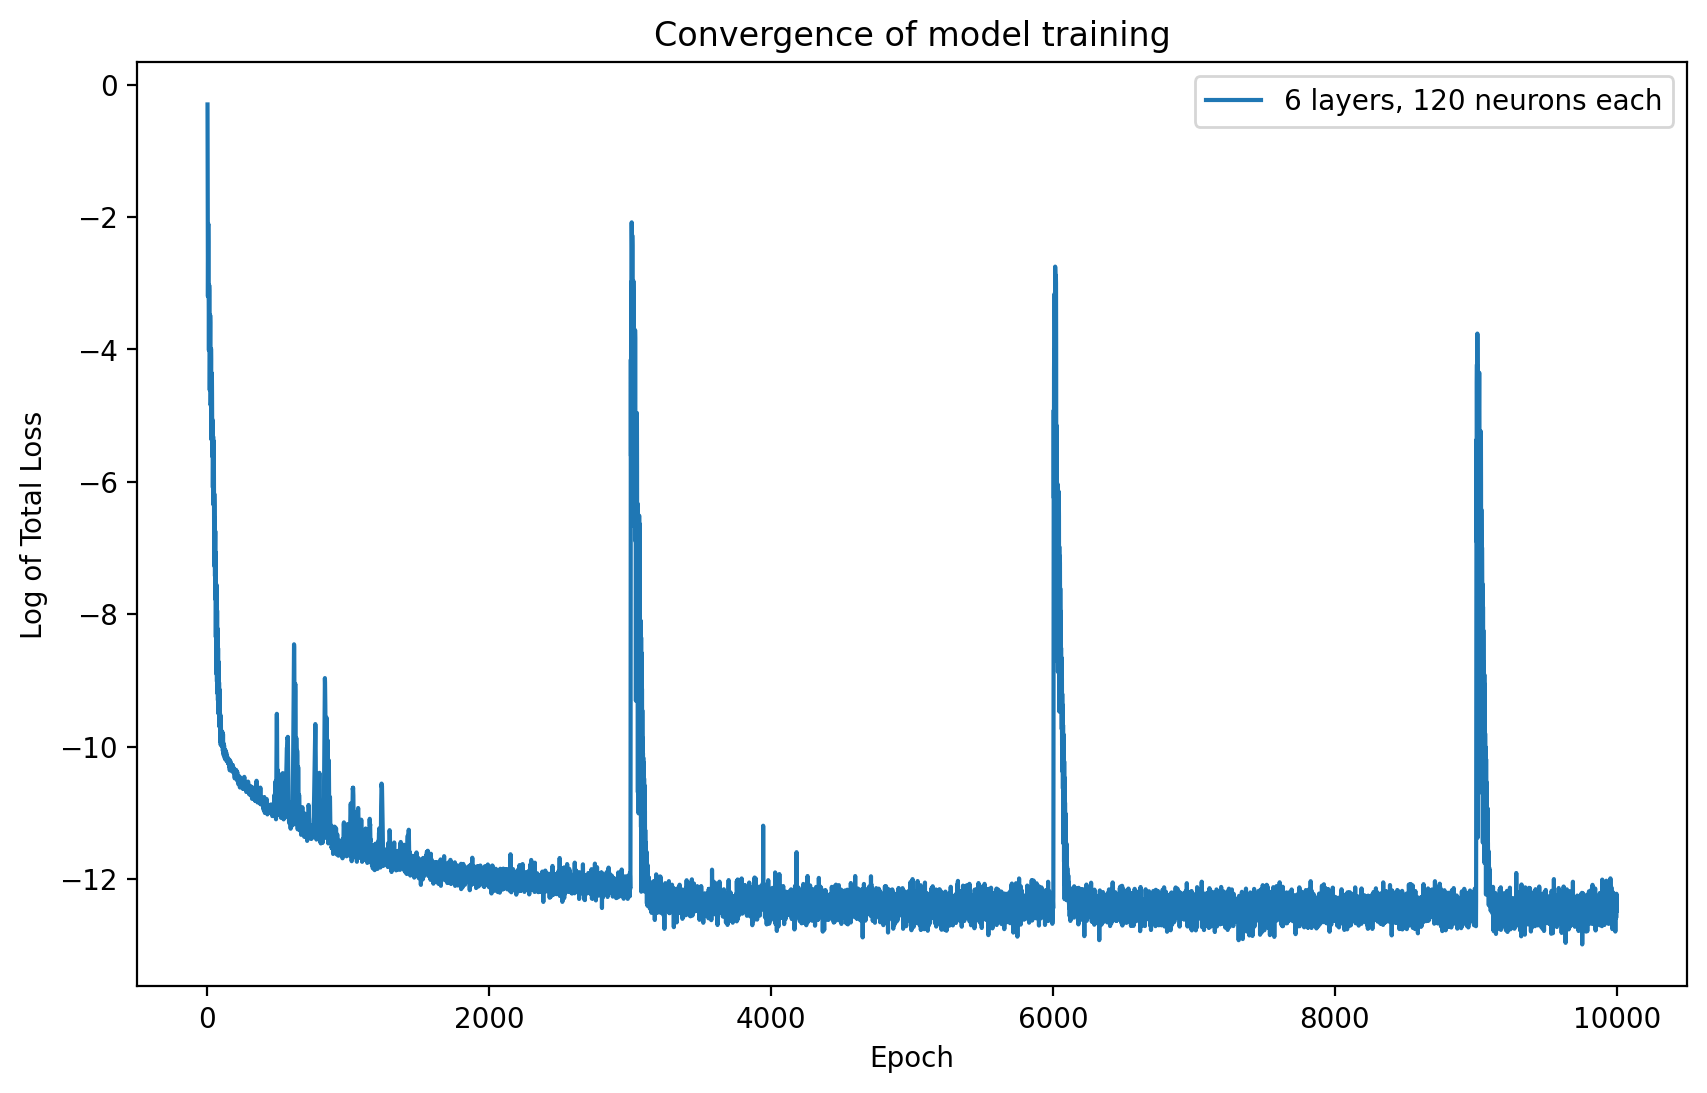

In [5]:
plot_convergence(history, x_axis = 'epochs')

In [9]:
# test the accuracy of the model against quasi-analytical pricing
results = heston_2d_slice_test(pinn = pinn, return_values = True, K=100)

MSE = 0.00028692923834374573
RMSE = 0.01693898575310062
MAE = 0.014391323780162463


In [28]:
0.0002 * 10000

2.0

In [10]:
plot_3d_result(results, 'diff')

In [ ]:
# testing multiple models
pinn_5_50 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=50, depth=5).to(device)
pinn_6_75 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=75, depth=6).to(device)
pinn_7_100 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=100, depth=7).to(device)

pinns = [pinn_5_50, pinn_6_75, pinn_7_100]
histories = []

for pinn in pinns:
    histories.append(train_network_heston(
        pinn=pinn,
        N_pde=4000,
        N_boundary=1000,
        epochs=30000,
        sigma_mode="mean_reverting",
        save_model=False, 
        lambda_boundary=1.0,
        lambda_terminal=0.5,   
        grad_clip=1.0,
        print_every=1000,
        lr=1e-4,               
    ))

Epoch      1 | Time:       1.25s | LR: 1.000e-04 | Total: 5.640021e+00 | PDE_x: 9.111318e-02 | Terminal_x: 5.659737e-01 | Boundary_x: 5.265921e+00 | GradNorm: 1.207e+02 | Best: 5.640021e+00 @ 1
Epoch   1000 | Time:      83.54s | LR: 9.554e-05 | Total: 3.431805e-05 | PDE_x: 1.850039e-05 | Terminal_x: 4.320330e-06 | Boundary_x: 1.365749e-05 | GradNorm: 6.490e-02 | Best: 3.271459e-05 @ 999
Epoch   2000 | Time:     166.36s | LR: 8.306e-05 | Total: 1.680814e-05 | PDE_x: 1.105754e-05 | Terminal_x: 1.211802e-06 | Boundary_x: 5.144700e-06 | GradNorm: 3.516e-02 | Best: 1.512946e-05 @ 1958
Epoch   3000 | Time:     247.27s | LR: 6.501e-05 | Total: 1.363725e-05 | PDE_x: 1.065429e-05 | Terminal_x: 8.296574e-07 | Boundary_x: 2.568130e-06 | GradNorm: 4.661e-03 | Best: 1.088053e-05 @ 2864
Epoch   4000 | Time:     328.27s | LR: 4.499e-05 | Total: 9.745225e-06 | PDE_x: 7.600248e-06 | Terminal_x: 5.869775e-07 | Boundary_x: 1.851487e-06 | GradNorm: 8.373e-03 | Best: 8.877591e-06 @ 3709
Epoch   5000 | Time

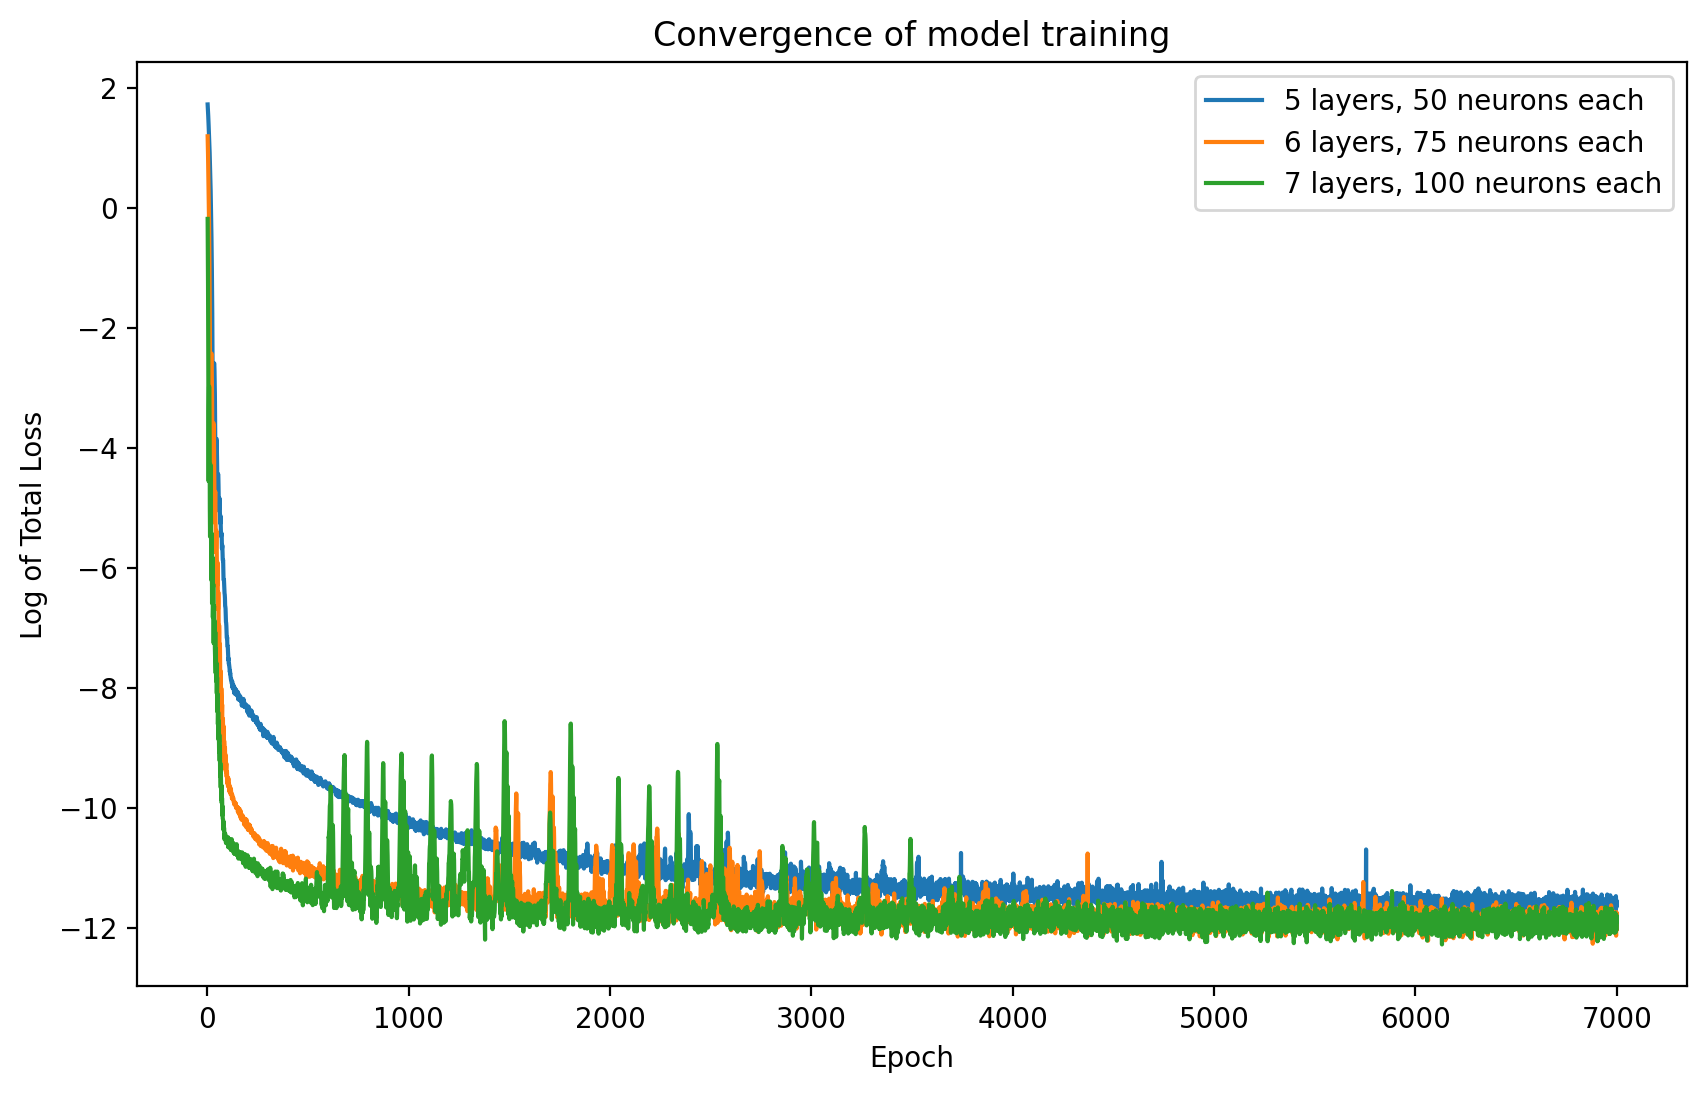

In [4]:
plot_convergence(histories, x_axis = 'epochs')

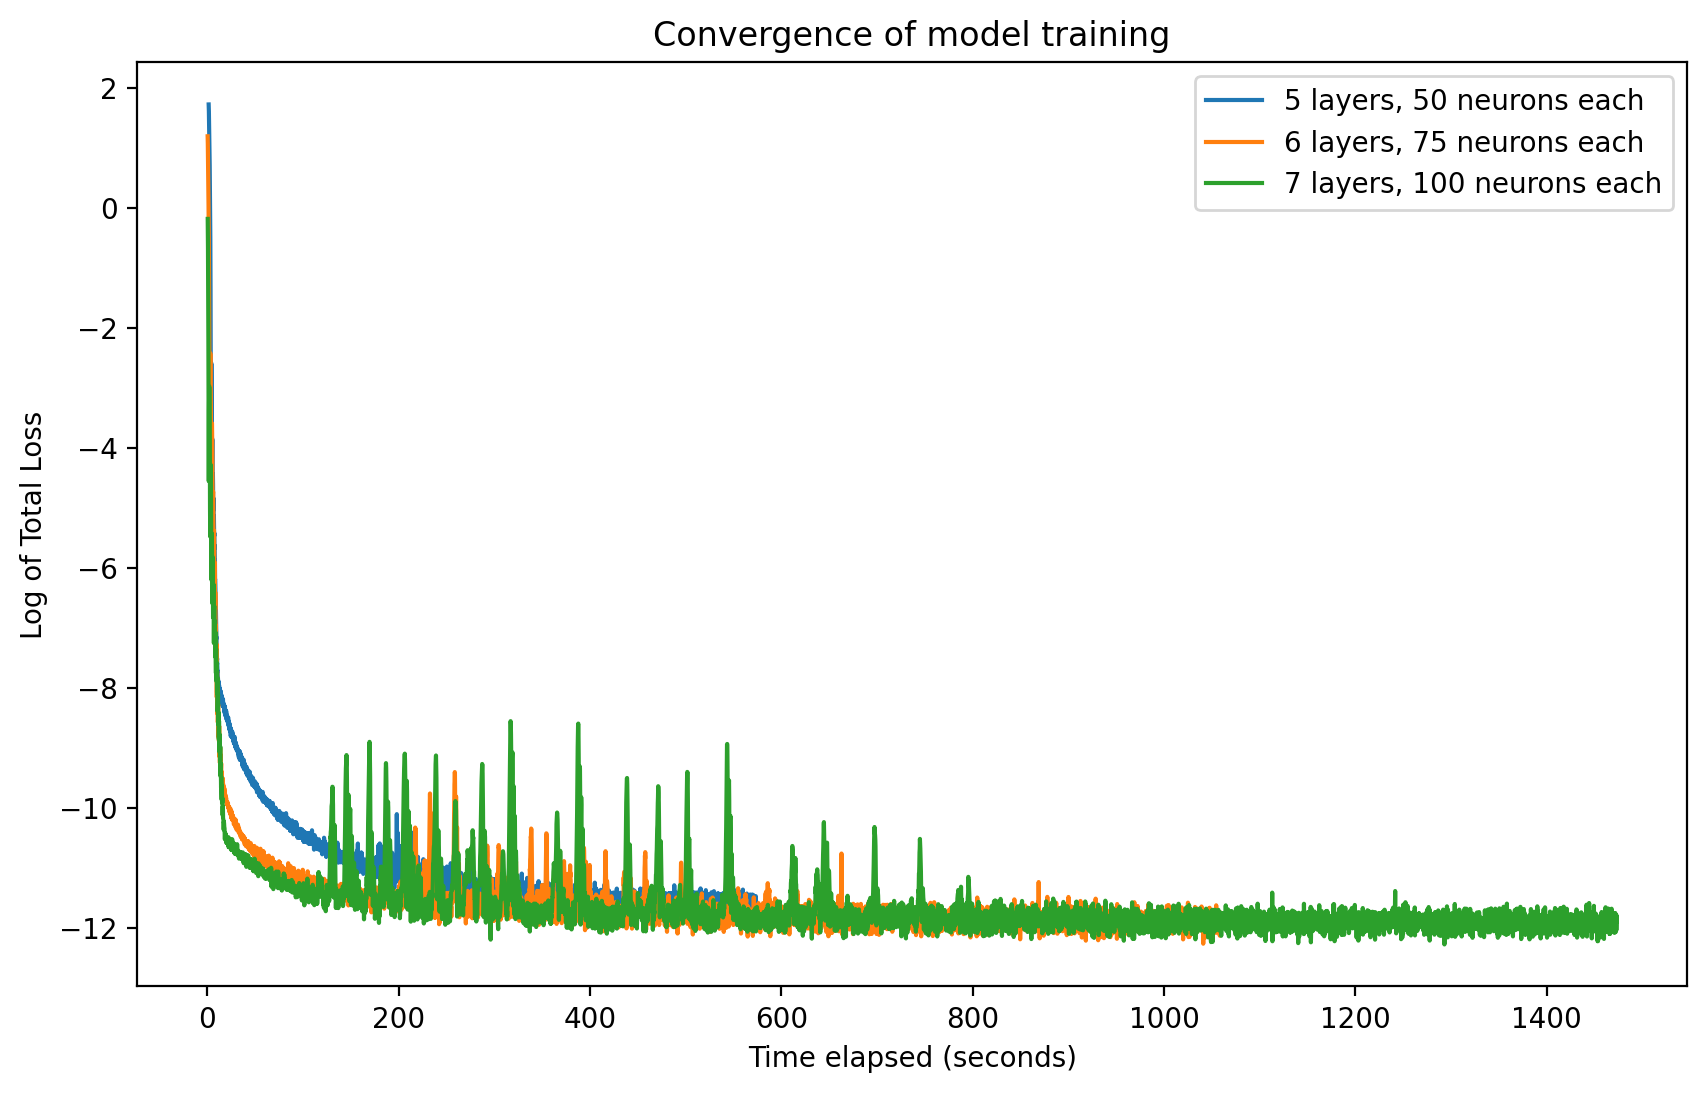

In [5]:
plot_convergence(histories, x_axis = 'elapsed_time')